In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
import scipy.stats as st
from matplotlib.colors import BoundaryNorm
# from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
# from matplotlib.figure import Figure
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
import seaborn as sns
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
xr.__version__

'2023.5.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    # "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
lon_range = [-65.4, -63.1]
lat_range = [-33.3, -30.8]
gridspacing_d3 = '500m'
gridspacing_d4 = '100m'

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 16
Number of W files (D2): 16
Number of ENV files (D2): 16
Number of stats files (D3): 16
Number of W files (D3): 16
Number of ENV files (D3): 16
Number of stats files (D4): 16
Number of W files (D4): 16
Number of ENV files (D4): 16


(['/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/stats/trackstats_20181219.1200_20181220.000

## Read & combine data files

In [5]:
# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 5007


<xarray.Dataset>
Dimensions:                  (tracks: 5007, times: 212, height: 101, z: 40,
                              core: 20)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 5003 5004 5005 5006
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 ... 13 14 15 16 17 18 19
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

(array([ 489.,  852., 1078.,  950.,  811.,  444.,  223.,   74.,   33.,
          53.]),
 array([  20.,  444.,  868., 1292., 1716., 2140., 2564., 2988., 3412.,
        3836., 4260.], dtype=float32),
 <BarContainer object of 10 artists>)

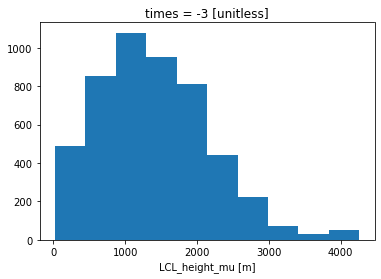

In [6]:
# ds = xr.open_dataset(files_d2[0], engine='netcdf4')
dse_d2.LCL_height_mu.sel(times=-3).plot.hist()

In [7]:
# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 8348


<xarray.Dataset>
Dimensions:                  (tracks: 8348, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8344 8345 8346 8347
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 6463


<xarray.Dataset>
Dimensions:                  (tracks: 6463, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6459 6460 6461 6462
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/188)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [9]:
# # Read track data (LASSO D2)
# dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# # Renumber tracks to make it continuous
# ntracks_d2 = dst_d2.sizes['tracks']
# dst_d2['tracks'] = np.arange(0, ntracks_d2)
# print(f'Number of tracks (D2): {ntracks_d2}')

# # Read W data (LASSO D2)
# dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# # Combine 2D and 3D datasets by coordinates
# ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2], combine_attrs='drop_conflicts')
# ntimes_d2 = ds_d2.sizes['times']
# ds_d2

In [10]:
# # Read track data (LASSO D3)
# dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# ntracks_d3 = dst_d3.sizes['tracks']
# dst_d3['tracks'] = np.arange(0, ntracks_d3)
# print(f'Number of tracks (D3): {ntracks_d3}')

# # Read W data (LASSO D3)
# dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# # Combine 2D and 3D datasets by coordinates
# ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3], combine_attrs='drop_conflicts')
# ntimes_d3 = ds_d3.sizes['times']
# ds_d3

In [11]:
# # Read track data (LASSO D4)
# # dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested').load()
# dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# ntracks_d4 = dst_d4.sizes['tracks']
# dst_d4['tracks'] = np.arange(0, ntracks_d4)
# print(f'Number of tracks (d4): {ntracks_d4}')

# # Read W data (LASSO D4)
# # dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested').load()
# dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# # Renumber tracks to make it continuous
# dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# # Combine 2D and 3D datasets by coordinates
# ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4], combine_attrs='drop_conflicts')
# # Trim times dimension to match D3
# ds_d4 = ds_d4.isel(times=slice(0, ntimes_d3))
# ds_d4

## Subset tracks

In [12]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 4031


In [13]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 6783


In [14]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 6311


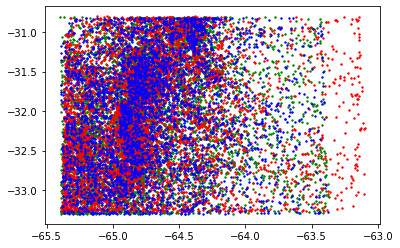

In [15]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [16]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-65.39175 -63.10074 -33.27073 -30.800056
[-65.4, -63.1] [-33.3, -30.8]


## Find merge/split track indices

In [17]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [18]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

## Subset DataSets with non-merge/non-split tracks

In [19]:
tid_d2['nms']

<xarray.DataArray (tracks: 4031)>
array([ True, False,  True, ...,  True, False, False])
Coordinates:
  * tracks   (tracks) int64 0 1 2 3 4 5 6 ... 4024 4025 4026 4027 4028 4029 4030

In [20]:
dss_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dss_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dss_d4 = ds_d4.isel(tracks=tid_d4['nms'])

In [21]:
# Get some constents common for all Datasets
ntimes = dss_d2.dims['times']
nz = dss_d2.dims['z']
ncores = dss_d2.dims['core']

time_res = 5.0  # [min]
xtime = dss_d2.times * time_res
height = dss_d2.z / 1000.

In [22]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dss_d2['track_duration'].load() * time_res
track_lifetime_d3 = dss_d3['track_duration'].load() * time_res
track_lifetime_d4 = dss_d4['track_duration'].load() * time_res

maxETH_10dbz_d2 = dss_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dss_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dss_d4['maxETH_10dbz'].load()

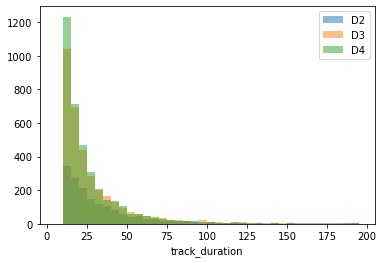

In [23]:
bins = np.arange(5,200,5)
track_lifetime_d2.plot.hist(bins=bins, alpha=0.5, label='D2')
track_lifetime_d3.plot.hist(bins=bins, alpha=0.5, label='D3')
track_lifetime_d4.plot.hist(bins=bins, alpha=0.5, label='D4')
plt.legend()

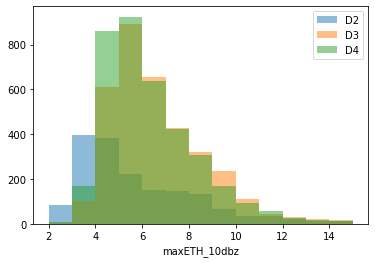

In [24]:
bins = np.arange(2,16,1)
maxETH_10dbz_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
maxETH_10dbz_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
maxETH_10dbz_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')
plt.legend()

## Get lifetime-max 10dBZ ETH distributions & percentile values

In [25]:
eth_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.75 6.  ]


In [26]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.25 6.   7.  ]


In [27]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(eth_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5]


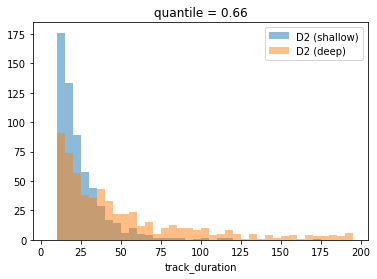

In [28]:
bins = np.arange(5,200,5)
track_lifetime_d2.where(trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (shallow)')
track_lifetime_d2.where(trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D2 (deep)')
plt.legend()

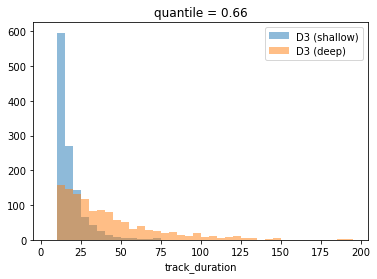

In [29]:
bins = np.arange(5,200,5)
track_lifetime_d3.where(trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=0.33), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (shallow)')
track_lifetime_d3.where(trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=0.66), drop=True).plot.hist(bins=bins, alpha=0.5, label='D3 (deep)')
plt.legend()

In [30]:
# CoreArea_up_d2 = dss_d2['CoreArea_up'].isel(core=0).load()
# CoreMaxW_up_d2 = dss_d2['CoreMaxW_up'].isel(core=0).load()

In [31]:
# CoreArea_up_d3 = dss_d3['CoreArea_up'].isel(core=0).load()
# CoreMaxW_up_d3 = dss_d3['CoreMaxW_up'].isel(core=0).load()

In [32]:
# CoreArea_up_d4 = dss_d4['CoreArea_up'].isel(core=0).load()
# CoreMaxW_up_d4 = dss_d4['CoreMaxW_up'].isel(core=0).load()

In [33]:
# CoreArea_up_d2.shape, trackmaxETH_10dbz_d2.shape

# Define shallow vs. deep cells
## Include duration threshold to both shallow/deep cells

In [34]:
track_lifetime_d2.shape, trackmaxETH_10dbz_d2.shape

((1712,), (1712,))

In [35]:
# Define cell lifetime range for filtering, unit: [min]
track_lifetime_range = [15,100]

# Select percentiles to define shallow vs. deep cells
percentile_shallow = eth_percentiles[0]
percentile_deep = eth_percentiles[2]
print(f'Percentile thresholds for shallow: {percentile_shallow}, deep: {percentile_deep}')

Percentile thresholds for shallow: 0.33, deep: 0.66


(array([  0.,   0.,   0.,   0.,   0.,   0., 119., 129., 107.,  60.,  34.,
         32.,  21.,  11.,  15.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

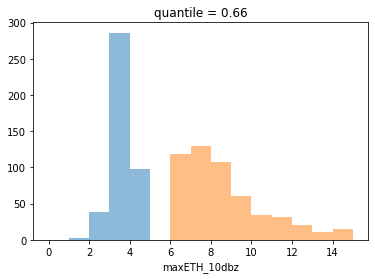

In [36]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d2 = (trackmaxETH_10dbz_d2 <= max10dbz_pts_d2.sel(quantile=percentile_shallow)) & (track_lifetime_d2 >= min(track_lifetime_range))
cid_deep_d2 = (trackmaxETH_10dbz_d2 >= max10dbz_pts_d2.sel(quantile=percentile_deep)) & (track_lifetime_d2 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d2.sel(tracks=cid_shallow_d2).plot.hist(bins=bins, alpha=0.5, label='D2 shallow')
trackmaxETH_10dbz_d2.sel(tracks=cid_deep_d2).plot.hist(bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0., 349., 273., 222., 104.,
         44.,  28.,  18.,  15.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

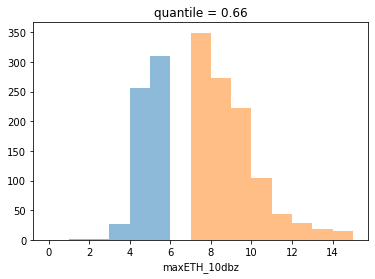

In [37]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d3 = (trackmaxETH_10dbz_d3 <= max10dbz_pts_d3.sel(quantile=percentile_shallow)) & (track_lifetime_d3 >= min(track_lifetime_range))
cid_deep_d3 = (trackmaxETH_10dbz_d3 >= max10dbz_pts_d3.sel(quantile=percentile_deep)) & (track_lifetime_d3 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d3.sel(tracks=cid_shallow_d3).plot.hist(bins=bins, alpha=0.5, label='d3 shallow')
trackmaxETH_10dbz_d3.sel(tracks=cid_deep_d3).plot.hist(bins=bins, alpha=0.5, label='d3 deep')

(array([  0.,   0.,   0.,   0.,   0.,   0., 227., 341., 276., 154.,  82.,
         55.,  26.,  15.,  13.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <BarContainer object of 15 artists>)

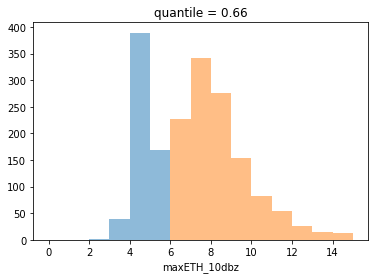

In [38]:
# Get shallow vs. deep cell/track IDs
cid_shallow_d4 = (trackmaxETH_10dbz_d4 <= max10dbz_pts_d4.sel(quantile=percentile_shallow)) & (track_lifetime_d4 >= min(track_lifetime_range))
cid_deep_d4 = (trackmaxETH_10dbz_d4 >= max10dbz_pts_d4.sel(quantile=percentile_deep)) & (track_lifetime_d4 >= min(track_lifetime_range))

# Check ETH histogram for shallow vs. deep groups
bins = np.arange(0,16,1)
trackmaxETH_10dbz_d4.sel(tracks=cid_shallow_d4).plot.hist(bins=bins, alpha=0.5, label='d4 shallow')
trackmaxETH_10dbz_d4.sel(tracks=cid_deep_d4).plot.hist(bins=bins, alpha=0.5, label='d4 deep')

## Subset DataSets by shallow vs. deep tracks

In [39]:
dss_shallow_d2 = dss_d2.sel(tracks=cid_shallow_d2)
dss_deep_d2 = dss_d2.sel(tracks=cid_deep_d2)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d2 = dss_shallow_d2['maxETH_10dbz'].load()
CoreArea_up_shallow_d2 = dss_shallow_d2['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()
CoreMaxW_up_shallow_d2 = dss_shallow_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d2+1).isel(core=0).load()

maxETH_10dbz_deep_d2 = dss_deep_d2['maxETH_10dbz'].load()
CoreArea_up_deep_d2 = dss_deep_d2['CoreArea_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()
CoreMaxW_up_deep_d2 = dss_deep_d2['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d2+1).isel(core=0).load()

In [40]:
dss_shallow_d3 = dss_d3.sel(tracks=cid_shallow_d3)
dss_deep_d3 = dss_d3.sel(tracks=cid_deep_d3)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d3 = dss_shallow_d3['maxETH_10dbz'].load()
CoreArea_up_shallow_d3 = dss_shallow_d3['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()
CoreMaxW_up_shallow_d3 = dss_shallow_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d3+1).isel(core=0).load()

maxETH_10dbz_deep_d3 = dss_deep_d3['maxETH_10dbz'].load()
CoreArea_up_deep_d3 = dss_deep_d3['CoreArea_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()
CoreMaxW_up_deep_d3 = dss_deep_d3['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d3+1).isel(core=0).load()

In [41]:
dss_shallow_d4 = dss_d4.sel(tracks=cid_shallow_d4)
dss_deep_d4 = dss_d4.sel(tracks=cid_deep_d4)

# Filter updrafts above 10dBZ ETH + 1 km
maxETH_10dbz_shallow_d4 = dss_shallow_d4['maxETH_10dbz'].load()
CoreArea_up_shallow_d4 = dss_shallow_d4['CoreArea_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()
CoreMaxW_up_shallow_d4 = dss_shallow_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_shallow_d4+1).isel(core=0).load()

maxETH_10dbz_deep_d4 = dss_deep_d4['maxETH_10dbz'].load()
CoreArea_up_deep_d4 = dss_deep_d4['CoreArea_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()
CoreMaxW_up_deep_d4 = dss_deep_d4['CoreMaxW_up'].where(height <= maxETH_10dbz_deep_d4+1).isel(core=0).load()

In [42]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d2 = (CoreArea_up_shallow_d2 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d2 = (CoreArea_up_deep_d2 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d2 = nsample_CoreArea_up_deep_d2.where(nsample_CoreArea_up_deep_d2 > 0)
nsample_CoreArea_up_shallow_d2 = nsample_CoreArea_up_shallow_d2.where(nsample_CoreArea_up_shallow_d2 > 0)

In [43]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d3 = (CoreArea_up_shallow_d3 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d3 = (CoreArea_up_deep_d3 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d3 = nsample_CoreArea_up_deep_d3.where(nsample_CoreArea_up_deep_d3 > 0)
nsample_CoreArea_up_shallow_d3 = nsample_CoreArea_up_shallow_d3.where(nsample_CoreArea_up_shallow_d3 > 0)

In [44]:
# Number of sample at each time & height for all tracks
nsample_CoreArea_up_shallow_d4 = (CoreArea_up_shallow_d4 > 0).sum(dim='tracks')
nsample_CoreArea_up_deep_d4 = (CoreArea_up_deep_d4 > 0).sum(dim='tracks')
# Make 0 sample NaN
nsample_CoreArea_up_deep_d4 = nsample_CoreArea_up_deep_d4.where(nsample_CoreArea_up_deep_d4 > 0)
nsample_CoreArea_up_shallow_d4 = nsample_CoreArea_up_shallow_d4.where(nsample_CoreArea_up_shallow_d4 > 0)

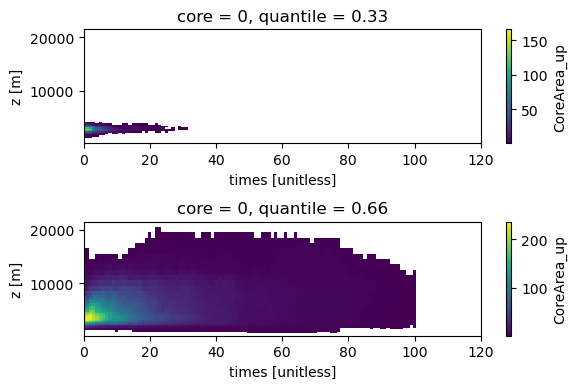

In [45]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d2.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d2.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

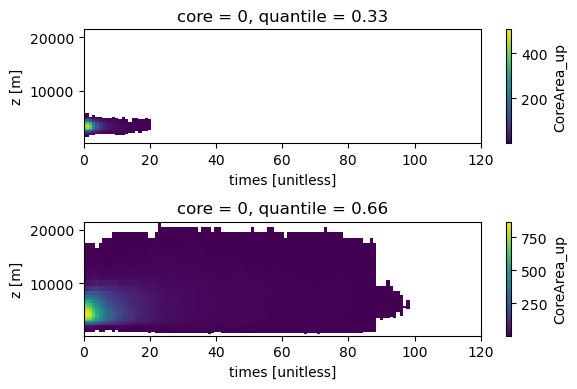

In [46]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d3.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d3.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

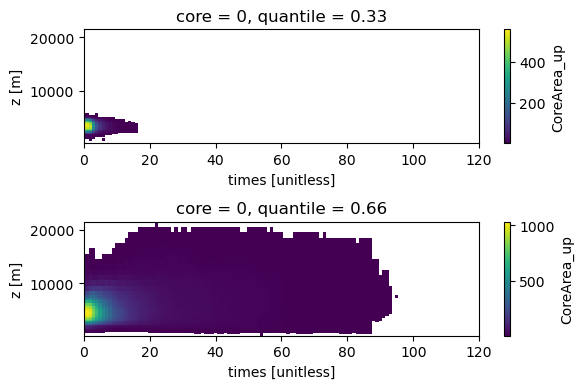

In [47]:
fig, axes = plt.subplots(2, 1, dpi=100)
nsample_CoreArea_up_shallow_d4.transpose().plot(ax=axes[0])
nsample_CoreArea_up_deep_d4.transpose().plot(ax=axes[1])
axes[0].set_xlim(0,120)
axes[1].set_xlim(0,120)
fig.tight_layout()

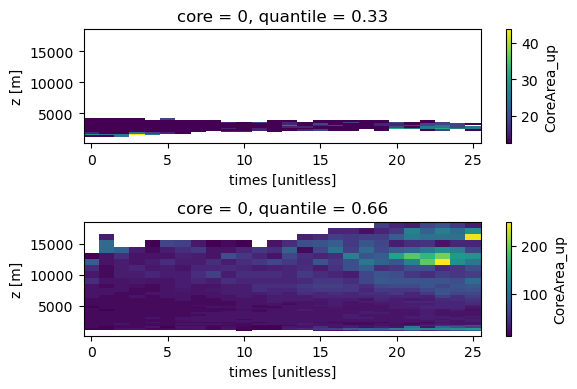

In [48]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

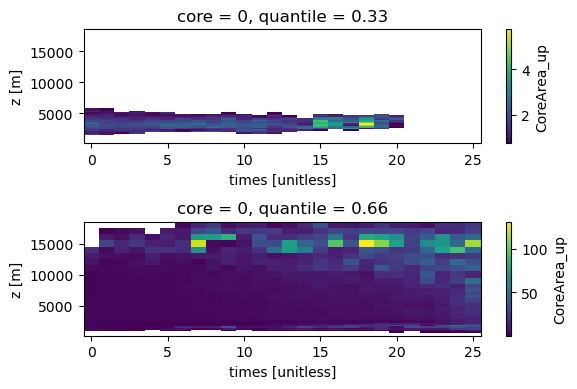

In [49]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d3.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d3.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

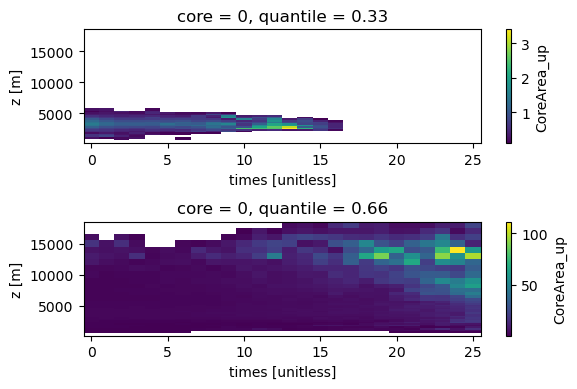

In [50]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreArea_up_shallow_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreArea_up_deep_d4.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

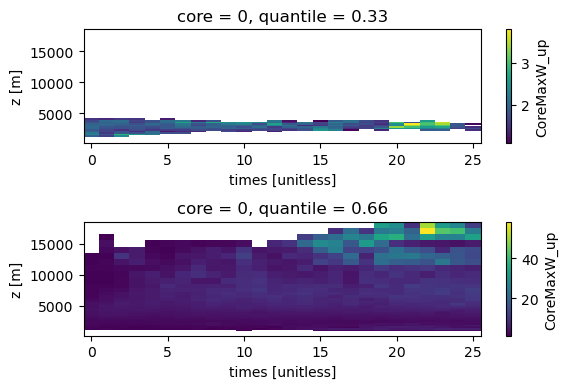

In [51]:
fig, axes = plt.subplots(2, 1, dpi=100)
CoreMaxW_up_shallow_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[0])
CoreMaxW_up_deep_d2.median(dim='tracks').transpose().sel(times=slice(0,25), z=slice(0,18000)).plot(ax=axes[1])
fig.tight_layout()

In [52]:
# plot individual tracks to check issues, particularly shallow ones

In [53]:
# maxETH_10dbz_
# dss_deep_d2.muc.plot.hist()

In [54]:
# Time for representative environment
time_env = -3

# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_deep_d2 = (dss_deep_d2['LCL_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_shallow_d2 = (dss_shallow_d2['LCL_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d2 = (dss_deep_d2['LFC_height_mu'] + dss_deep_d2['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d2 = (dss_shallow_d2['LFC_height_mu'] + dss_shallow_d2['Z_surface']).sel(times=time_env) / 1000.

(array([  5.,  56., 132., 175.,  91.,  47.,  15.,   4.,   0.,   2.]),
 array([0.54578173, 1.1417974 , 1.7378131 , 2.3338287 , 2.9298444 ,
        3.52586   , 4.121876  , 4.7178917 , 5.313907  , 5.909923  ,
        6.5059385 ], dtype=float32),
 <BarContainer object of 10 artists>)

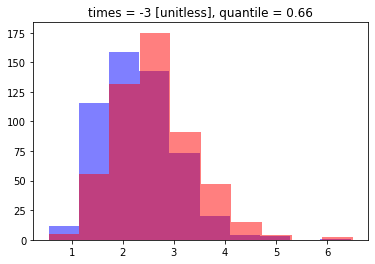

In [55]:
LCL_mu_deep_d2.plot.hist(color='b', alpha=0.5)
LFC_mu_deep_d2.plot.hist(color='r', alpha=0.5)

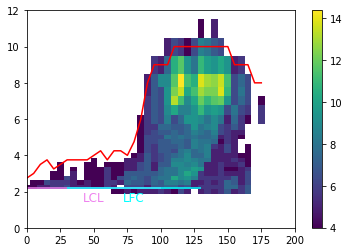

In [69]:
plt.pcolormesh(xtime, height, 2*np.sqrt(CoreArea_up_deep_d2.isel(tracks=1).transpose()/np.pi), shading='nearest')
plt.plot(xtime, maxETH_10dbz_deep_d2.isel(tracks=1), color='r')
line_length = 100
LCL_t0 = 0
LCL_t1 = LCL_t0 + line_length
LFC_t0 = 30
LFC_t1 = LFC_t0 + line_length
plt.hlines(y=LCL_mu_deep_d2.isel(tracks=1), xmin=LCL_t0, xmax=LCL_t1, color='violet')
plt.hlines(y=LFC_mu_deep_d2.isel(tracks=1), xmin=LFC_t0, xmax=LFC_t1, color='cyan')
LCL_text_x = LCL_t0 + line_length / 2
LCL_text_y = LCL_mu_deep_d2.isel(tracks=1)-0.2
LFC_text_x = LFC_t0 + line_length / 2
LFC_text_y = LFC_mu_deep_d2.isel(tracks=1)-0.2
plt.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color='violet', fontsize=12)
plt.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color='cyan', fontsize=12)
plt.xlim(0,200)
plt.ylim(0,12)
plt.colorbar()

In [57]:
# Get updraft track coordinates
c_times = CoreMaxW_up_deep_d2.coords['times'].data
c_z = CoreMaxW_up_deep_d2.coords['z'].data

# Define a time window to sample updraft
time_start = 0  # [min]
time_end = 60  # [min]
# tidx_start = int(time_start / time_res)
# tidx_end = int(time_end / time_res)
tidx_start = np.where(xtime == time_start)[0].item()
tidx_end = np.where(xtime == time_end)[0].item()
print(tidx_start, tidx_end)

12 24


In [58]:
xtime.data[tidx_start], xtime.data[tidx_end]

(0.0, 60.0)

In [59]:
CoreArea_up_deep_d2.shape, CoreMaxW_up_deep_d2.shape, maxETH_10dbz_deep_d2.shape

((531, 212, 40), (531, 212, 40), (531, 212))

## Make 2D updraft object masks for each track 

In [96]:
def make_W_mask(da_W):

    # Make a binary array for W
    binary_w = np.zeros_like(da_W)
    binary_w[da_W > 0] = 1
    
    # Make output arrays
    _ntracks = da_W.sizes['tracks']
    _ntimes = da_W.sizes['times']
    Wmask = np.full(da_W.shape, np.NaN)
    Wmask_plt = np.full(da_W.shape, np.NaN)
    Wtime_start = np.full(_ntracks, np.NaN)
    Wtime_end = np.full(_ntracks, np.NaN)
    Wlifetime = np.full(_ntracks, np.NaN)
    Wtop = np.full((_ntracks, _ntimes), np.NaN)
    Wbase = np.full((_ntracks, _ntimes), np.NaN)

    # Loop over each track
    for itrack in range(0, _ntracks):
        # Get the binary mask for this track
        iW_binary = binary_w[itrack,:,:].squeeze()

        # Label the connected pixels
        label_image, n_obj = label(iW_binary > 0)
        # Trim the times, then get the unique values of the labeled image, and the pixel counts
        label_num_, npix_ = np.unique(label_image[tidx_start:tidx_end,:], return_counts=True)
        # Trim the 0 (not an object), then count the number of W objects
        label_num_W = np.trim_zeros(label_num_)
        n_obj_W = len(label_num_W)

        mask_time2d = np.zeros(label_image.shape)
        mask_small = np.full(label_image.shape, np.NaN)
        mask_small_plt = np.full(label_image.shape, np.NaN)
        max_indices_z = np.full(label_image.shape, -1, dtype=int)
        mask_top = np.full(label_image.shape[0], np.NaN)
        mask_base = np.full(label_image.shape[0], np.NaN)

        # Get the size (pixel count) of the W objects
        if n_obj_W > 0:
            # Exclude the first value (0)
            npix_W = npix_[1:]
    #         print(label_num_W, npix_W)
            # Get the largest object number
            big_cell = label_num_W[np.argmax(npix_W)]

            # Mask time period to keep object    
            mask_time2d[tidx_start:tidx_end+1,:] = 1
            # Make a binary mask of the largest object
            mask_small[(label_image==big_cell) & (mask_time2d==1)] = 1
            # Make a mask for small objects
            mask_small_plt[(mask_small != 1) & (iW_binary > 0)] = 1

            #------------------------------------
            # Get updraft top heights
            # Get indices of the last occurrence of the max value along the y-axis (height)
            max_indices_z = np.argmax(mask_small[:,::-1]==1, axis=1)
            # Invert the indices to get the correct position along the original y-axis
            max_indices_z = mask_small.shape[1] - 1 - max_indices_z
            # Filter out indices where the mask is False
            max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
            # Apply indices to height array using advanced indexing
            mask_top = height.data[max_indices_z]
            # Replace times when indices is invalid with NaN (< 0)
            mask_top[max_indices_z < 0] = np.NaN
            #------------------------------------
            
            min_indices_z = np.argmax(mask_small==1, axis=1)
            min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
            mask_base = height.data[min_indices_z]
            mask_base[min_indices_z < 0] = np.NaN

            # Find start/end time indices of the largest object
            tind, zind = np.where(label_image==big_cell)
            istart, iend = min(tind), max(tind)
            # Put time indices in a dictionary
    #         Wtime_startend = {'s':xtime[istart], 'e':xtime[iend]}
            # Updraft lifetime
    #         Wlifetime = (iend - istart + 1) * time_res

            # Save values to output arrays
            Wmask[itrack,:,:] = mask_small
            Wmask_plt[itrack,:,:] = mask_small_plt
            Wtop[itrack,:] = mask_top
            Wbase[itrack,:] = mask_base
            Wtime_start[itrack] = xtime[istart]
            Wtime_end[itrack] = xtime[iend]
            Wlifetime[itrack] = (iend - istart + 1) * time_res            

    # Convert to DataArrays
    Wmask = xr.DataArray(Wmask, coords=da_W.coords, dims=('tracks','times','z'))
    Wmask_plt = xr.DataArray(Wmask_plt, coords=da_W.coords, dims=('tracks','times','z'))
    Wtop = xr.DataArray(Wtop, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wbase = xr.DataArray(Wbase, coords={'tracks':da_W.coords['tracks'], 'times':da_W.coords['times']}, dims=('tracks','times'))
    Wtime_start = xr.DataArray(Wtime_start, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wtime_end = xr.DataArray(Wtime_end, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    Wlifetime = xr.DataArray(Wlifetime, coords={'tracks':da_W.coords['tracks']}, dims=('tracks'))
    # Put outputs in a dictionary
    out_dict = {
        'Wmask': Wmask,
        'Wmask_plt': Wmask_plt,
        'Wtop': Wtop,
        'Wbase': Wbase,
        'Wtime_start': Wtime_start,
        'Wtime_end': Wtime_end,
        'Wlifetime': Wlifetime,        
    }
    return out_dict

In [97]:
Wmask_dict_deep_d2 = make_W_mask(CoreArea_up_deep_d2)
Wmask_dict_shallow_d2 = make_W_mask(CoreArea_up_shallow_d2)

/tmp/ipykernel_2147013/2924319859.py:60: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_2147013/2924319859.py:68: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [126]:
Wmask_dict_deep_d3 = make_W_mask(CoreArea_up_deep_d3)
Wmask_dict_shallow_d3 = make_W_mask(CoreArea_up_shallow_d3)

/tmp/ipykernel_2147013/2924319859.py:60: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_2147013/2924319859.py:68: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [127]:
Wmask_dict_deep_d4 = make_W_mask(CoreArea_up_deep_d4)
Wmask_dict_shallow_d4 = make_W_mask(CoreArea_up_shallow_d4)

/tmp/ipykernel_2147013/2924319859.py:60: RuntimeWarning: All-NaN slice encountered
  max_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1
/tmp/ipykernel_2147013/2924319859.py:68: RuntimeWarning: All-NaN slice encountered
  min_indices_z[np.isnan(np.nanmax(mask_small, axis=1))] = -1


In [64]:
# Wmask_dict_deep_d2['Wlifetime'].sizes['tracks']

In [65]:
# CoreArea_up_shallow_d2.isel(times=slice(tidx_start,tidx_end)).plot.hist()

(array([ 0., 38., 29., 48., 45., 29., 36., 30., 24., 19., 22., 16.,  5.,
         8., 12., 11.,  2.,  7., 10.]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
        85, 90, 95]),
 <BarContainer object of 19 artists>)

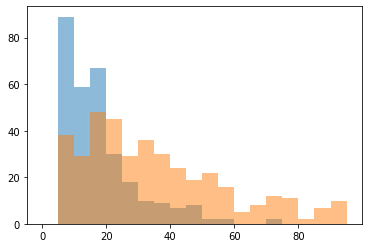

In [66]:
bins = np.arange(0, 100, 5)
plt.hist(Wmask_dict_shallow_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d2['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,  25.,  58., 142., 131., 112.,  87.,  82.,  44.,  47.,  44.,
         32.,  29.,  22.,  23.,  15.,  18.,  10.,  15.]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
        85, 90, 95]),
 <BarContainer object of 19 artists>)

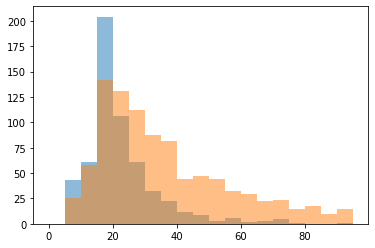

In [67]:
bins = np.arange(0, 100, 5)
plt.hist(Wmask_dict_shallow_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d3['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

(array([  0.,  30.,  28., 193., 150., 119., 110.,  83.,  79.,  74.,  46.,
         35.,  33.,  31.,  21.,  19.,  12.,  19.,  17.]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
        85, 90, 95]),
 <BarContainer object of 19 artists>)

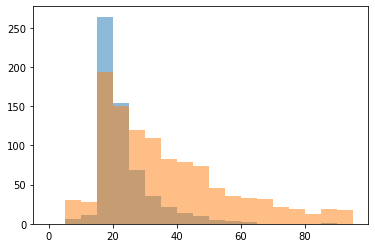

In [68]:
bins = np.arange(0, 100, 5)
plt.hist(Wmask_dict_shallow_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 shallow')
plt.hist(Wmask_dict_deep_d4['Wlifetime'], bins=bins, alpha=0.5, label='D2 deep')

## Subset tracks based on W statistics

In [70]:
# nsample_CoreArea_up_shallow_d2.shape, CoreMaxW_up_shallow_d2.shape
track_lifetime_range

[15, 100]

In [71]:
# Convert track_lifetime_range to time indices
track_duration_range = (np.array(track_lifetime_range) / time_res).astype(int)
track_duration_range

array([ 3, 20])

In [129]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d2 = (Wmask_dict_shallow_d2['Wlifetime'] > 0)
Wid_deep_d2 = (Wmask_dict_deep_d2['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d2sub = dss_shallow_d2.sel(tracks=Wid_shallow_d2)
dss_deep_d2sub = dss_deep_d2.sel(tracks=Wid_deep_d2)

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d2sub = CoreMaxW_up_shallow_d2.isel(tracks=Wid_shallow_d2)
CoreArea_up_shallow_d2sub = CoreArea_up_shallow_d2.isel(tracks=Wid_shallow_d2)
maxETH_10dbz_shallow_d2sub = maxETH_10dbz_shallow_d2.isel(tracks=Wid_shallow_d2)

CoreMaxW_up_deep_d2sub = CoreMaxW_up_deep_d2.isel(tracks=Wid_deep_d2)
CoreArea_up_deep_d2sub = CoreArea_up_deep_d2.isel(tracks=Wid_deep_d2)
maxETH_10dbz_deep_d2sub = maxETH_10dbz_deep_d2.isel(tracks=Wid_deep_d2)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d2sub = {}
Wmask_dict_deep_d2sub = {}
for key, var in Wmask_dict_shallow_d2.items():
    Wmask_dict_shallow_d2sub[key] = Wmask_dict_shallow_d2[key].isel(tracks=Wid_shallow_d2)
    Wmask_dict_deep_d2sub[key] = Wmask_dict_deep_d2[key].isel(tracks=Wid_deep_d2)

In [130]:
# CoreMaxW_up_shallow_d2.isel(tracks=Wid_shallow_d2).tracks

In [131]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d3 = (Wmask_dict_shallow_d3['Wlifetime'] > 0)
Wid_deep_d3 = (Wmask_dict_deep_d3['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d3sub = dss_shallow_d3.sel(tracks=Wid_shallow_d3)
dss_deep_d3sub = dss_deep_d3.sel(tracks=Wid_deep_d3)

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d3sub = CoreMaxW_up_shallow_d3.isel(tracks=Wid_shallow_d3)
CoreArea_up_shallow_d3sub = CoreArea_up_shallow_d3.isel(tracks=Wid_shallow_d3)
maxETH_10dbz_shallow_d3sub = maxETH_10dbz_shallow_d3.isel(tracks=Wid_shallow_d3)

CoreMaxW_up_deep_d3sub = CoreMaxW_up_deep_d3.isel(tracks=Wid_deep_d3)
CoreArea_up_deep_d3sub = CoreArea_up_deep_d3.isel(tracks=Wid_deep_d3)
maxETH_10dbz_deep_d3sub = maxETH_10dbz_deep_d3.isel(tracks=Wid_deep_d3)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d3sub = {}
Wmask_dict_deep_d3sub = {}
for key, var in Wmask_dict_shallow_d3.items():
    Wmask_dict_shallow_d3sub[key] = Wmask_dict_shallow_d3[key].isel(tracks=Wid_shallow_d3)
    Wmask_dict_deep_d3sub[key] = Wmask_dict_deep_d3[key].isel(tracks=Wid_deep_d3)

In [132]:
# Find track indices where updraft objects exist (Wmask lifetime > 0)
Wid_shallow_d4 = (Wmask_dict_shallow_d4['Wlifetime'] > 0)
Wid_deep_d4 = (Wmask_dict_deep_d4['Wlifetime'] > 0)

# Subset shallow/deep DataSets using the track indices
dss_shallow_d4sub = dss_shallow_d4.sel(tracks=Wid_shallow_d4)
dss_deep_d4sub = dss_deep_d4.sel(tracks=Wid_deep_d4)

# Subset these variables as they are already loaded in memory
CoreMaxW_up_shallow_d4sub = CoreMaxW_up_shallow_d4.isel(tracks=Wid_shallow_d4)
CoreArea_up_shallow_d4sub = CoreArea_up_shallow_d4.isel(tracks=Wid_shallow_d4)
maxETH_10dbz_shallow_d4sub = maxETH_10dbz_shallow_d4.isel(tracks=Wid_shallow_d4)

CoreMaxW_up_deep_d4sub = CoreMaxW_up_deep_d4.isel(tracks=Wid_deep_d4)
CoreArea_up_deep_d4sub = CoreArea_up_deep_d4.isel(tracks=Wid_deep_d4)
maxETH_10dbz_deep_d4sub = maxETH_10dbz_deep_d4.isel(tracks=Wid_deep_d4)

# Subset tracks for the W mask dictionary
Wmask_dict_shallow_d4sub = {}
Wmask_dict_deep_d4sub = {}
for key, var in Wmask_dict_shallow_d4.items():
    Wmask_dict_shallow_d4sub[key] = Wmask_dict_shallow_d4[key].isel(tracks=Wid_shallow_d4)
    Wmask_dict_deep_d4sub[key] = Wmask_dict_deep_d4[key].isel(tracks=Wid_deep_d4)

In [133]:
# Time for representative environment [time indices]
time_env = -3

# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d2sub = (dss_shallow_d2sub['LCL_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d2sub = (dss_deep_d2sub['LCL_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d2sub = (dss_shallow_d2sub['LFC_height_mu'] + dss_shallow_d2sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d2sub = (dss_deep_d2sub['LFC_height_mu'] + dss_deep_d2sub['Z_surface']).sel(times=time_env) / 1000.

In [134]:
# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d3sub = (dss_shallow_d3sub['LCL_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d3sub = (dss_deep_d3sub['LCL_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d3sub = (dss_shallow_d3sub['LFC_height_mu'] + dss_shallow_d3sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d3sub = (dss_deep_d3sub['LFC_height_mu'] + dss_deep_d3sub['Z_surface']).sel(times=time_env) / 1000.

In [135]:
# Convert HAMSL to AGL, then select a representative time before CI
LCL_mu_shallow_d4sub = (dss_shallow_d4sub['LCL_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
LCL_mu_deep_d4sub = (dss_deep_d4sub['LCL_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_shallow_d4sub = (dss_shallow_d4sub['LFC_height_mu'] + dss_shallow_d4sub['Z_surface']).sel(times=time_env) / 1000.
LFC_mu_deep_d4sub = (dss_deep_d4sub['LFC_height_mu'] + dss_deep_d4sub['Z_surface']).sel(times=time_env) / 1000.

## Function to plot individual tracks of updrafts

In [114]:
def plot_tz_sample(xtime, height, da, da_mask, maxETH, cldTop, cldBase, Wtime_startend, env_dict,
                   xlim=None, ylim=None, xlabel=None, ylabel=None, title=None, legend=None,
                   cmap=None, cblabels=None, fontsize=None, figsize=None, figname=None):
    
    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['figure.facecolor'] = 'white'

    fig = plt.figure(figsize=figsize, dpi=100)
    nrows = 1
    gs = gridspec.GridSpec(nrows, 2, height_ratios=np.repeat(1, nrows).tolist(), width_ratios=[1,0.04])
    gs.update(left=0.05, right=0.9, bottom=0.05, top=0.95, wspace=0.1, hspace=0.15)
    ax = plt.subplot(gs[0,0])
    cax = plt.subplot(gs[0,1])
    
    colors = {'ETH':'red', 'cldTop':'b', 'cldBase':'dodgerblue', 'LCL':'violet', 'LFC':'mediumorchid'}
    
    # Plot data
    pcm_da = ax.pcolormesh(xtime, height, da, shading='nearest', cmap=cmap)
    # Plot mask
    pcm_ma = ax.pcolormesh(xtime, height, da_mask, vmin=0., vmax=1, cmap='gray', alpha=0.8)
    # 
    ax.axvline(Wtime_startend['s'], lw=1, color='purple')
    ax.axvline(Wtime_startend['e'], lw=1, color='purple')
    ax.axvline(time_end, lw=1, ls=':', color='purple')
    # ETH line
    ETH_line = ax.plot(xtime, maxETH, color=colors['ETH'], label='10dBZ ETH')
    # cloud/updraft top line
    cldTop_line = ax.plot(xtime, cldTop, color=colors['cldTop'], label='Updraft Top')
    cldBase_line = ax.plot(xtime, cldBase, color=colors['cldBase'], label='Updraft Base')
    
    LCL = env_dict['LCL']
    LFC = env_dict['LFC']

    line_length = 50
    LCL_t0 = 0
    LCL_t1 = LCL_t0 + line_length
    LFC_t0 = 30
    LFC_t1 = LFC_t0 + line_length
    ax.hlines(y=LCL, xmin=LCL_t0, xmax=LCL_t1, color=colors['LCL'])
    ax.hlines(y=LFC, xmin=LFC_t0, xmax=LFC_t1, color=colors['LFC'], ls='--')
    LCL_text_x = LCL_t0 + line_length / 2
    LCL_text_y = LCL-0.2
    LFC_text_x = LFC_t0 + line_length / 2
    LFC_text_y = LFC-0.2
    ax.text(LCL_text_x, LCL_text_y, 'LCL', ha='center', va='top', color=colors['LCL'], fontsize=fontsize)
    ax.text(LFC_text_x, LFC_text_y, 'LFC', ha='center', va='top', color=colors['LFC'], fontsize=fontsize)
    
    ax.legend(fontsize=fontsize*0.7)
    # Draw an arrow below xaxis
    ax.annotate("", xy=(1, -0.2), xycoords='axes fraction', xytext=(0, -0.2), arrowprops=dict(facecolor='black'))
    # 
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.grid(ls='--')
    # Colorbar
    cb = plt.colorbar(pcm_da, cax=cax, label=cblabels,)
    
    fig.savefig(figname, bbox_inches='tight', dpi=200, facecolor='w')
    return fig

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0032.png


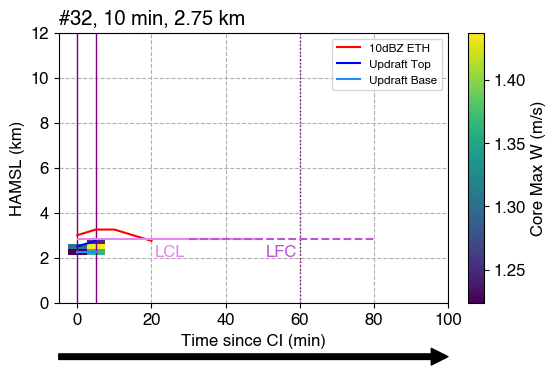

In [115]:
itrack = 32

_da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
_maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
_da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
_Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
_WBase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
_t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
_t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
_Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
_env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

xlim = (-5,100)
ylim = (0,12)
title = f'#{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
cmap = 'viridis'
cblabels = 'Core Max W (m/s)'
figbasename = 'CoreMaxW'
# cblabels = 'Core Width (km)'
# figbasename = 'CoreWidth'
figdir_sample = f'{figdir}/updraft_tracks/'
os.makedirs(figdir_sample, exist_ok=True)

figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
figsize = (5,3)
fontsize = 12

fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _WBase, _Wtime_startend, _env_dict,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# plt.close(fig)
print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0005.png


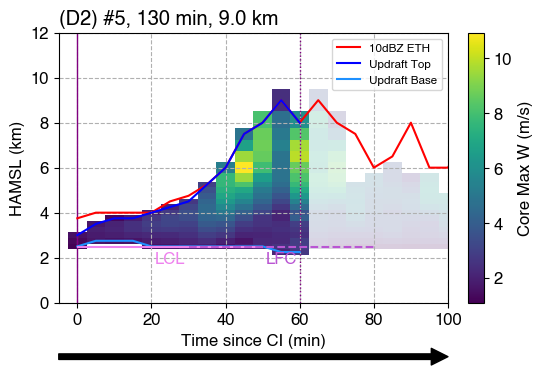

In [116]:
itrack = 5

_da = CoreMaxW_up_deep_d2sub.isel(tracks=itrack).transpose()
_maxETH = maxETH_10dbz_deep_d2sub.isel(tracks=itrack)
_da_mask = Wmask_dict_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
_Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
_WBase = Wmask_dict_deep_d2sub['Wbase'].isel(tracks=itrack)
_t_s = Wmask_dict_deep_d2sub['Wtime_start'].isel(tracks=itrack)
_t_e = Wmask_dict_deep_d2sub['Wtime_end'].isel(tracks=itrack)
_Wlifetime = Wmask_dict_deep_d2sub['Wlifetime'].isel(tracks=itrack)
_Wtime_startend = {'s':_t_s, 'e':_t_e}
_WtopMax = _Wtop.max(dim='times').item()
_env_dict = {'LCL':LCL_mu_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d2sub.isel(tracks=itrack)}

xlim = (-5,100)
ylim = (0,12)
title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
xlabel = 'Time since CI (min)'
ylabel = 'HAMSL (km)'
cmap = 'viridis'
cblabels = 'Core Max W (m/s)'
figbasename = 'CoreMaxW'
# cblabels = 'Core Width (km)'
# figbasename = 'CoreWidth'
figdir_sample = f'{figdir}/updraft_tracks/'
figname = f'{figdir_sample}{figbasename}_d2_deep_{itrack:04}.png'
figsize = (5,3)
fontsize = 12

fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _WBase, _Wtime_startend, _env_dict,
                     xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                     cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
# plt.close(fig)
print(figname)

In [117]:
figdir_sample

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/'

In [118]:
# for itrack in range(0, CoreMaxW_up_deep_d2sub.sizes['tracks']):
#     print(itrack)

In [119]:
# Set a seed for reproducibility
np.random.seed(10)

nsamples2plot = 100
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d2sub.sizes['tracks'], nsamples2plot)
tracks_random

array([265, 125,  15, 123, 156, 221,   8,  73, 256,  40,  16, 239,  54,
       122,  62,  33, 200, 177, 179,  54,  77,  13, 243, 141, 286, 158,
        89, 140,  31, 292, 283,  18,  93,  77,  94, 248, 156,  74, 216,
        15,  18, 118,  71, 145, 135, 203, 284, 289, 250,  44, 133,   4,
        71, 182, 290, 271, 143, 134, 246,  85, 234, 150,  11, 112, 268,
       220,  62, 185,  79, 232,  42, 237, 235,  45, 201, 165, 128,  23,
         3, 285, 272, 112,  14,  51,  79, 243, 273, 178,  53, 234, 273,
       233,  41,  90, 268, 286, 209, 144, 128, 159])

In [120]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d2sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d2_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0357.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0201.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0448.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0244.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0380.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0422.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0254.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0022.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0096.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0322.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

In [122]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d2sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d2sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d2sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d2sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d2sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d2sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d2sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d2sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d2sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d2sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d2sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D2) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d2_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0048.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0155.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0177.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0265.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0283.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0113.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0023.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0147.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0048.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_shallow_0225.png
/gpfs/wolf

In [136]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d3sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d3sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d3sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d3sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d3sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d3sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d3sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d3sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d3sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d3sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d3sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D3) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d3_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0505.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0083.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0019.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0063.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0351.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0473.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0547.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0094.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0322.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_shallow_0251.png
/gpfs/wolf

In [137]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d3sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d3sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d3sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d3sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d3sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d3sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d3sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d3sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d3sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d3sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d3sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D3) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d3_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0574.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0933.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0187.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1017.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0812.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0566.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0023.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0646.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_0138.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d3_deep_1013.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

In [138]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_shallow_d4sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_shallow_d4sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_shallow_d4sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_shallow_d4sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_shallow_d4sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_shallow_d4sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_shallow_d4sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_shallow_d4sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_shallow_d4sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_shallow_d4sub.isel(tracks=itrack), 'LFC':LFC_mu_shallow_d4sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D4) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d4_shallow_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0468.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0393.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0587.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0205.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0286.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0249.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0253.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0302.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0079.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_shallow_0410.png
/gpfs/wolf

In [139]:
# Generate a random number of tracks
tracks_random = np.random.randint(0, CoreMaxW_up_deep_d4sub.sizes['tracks'], nsamples2plot)

# Loop over each track to plot
for itrack in tracks_random:
    _da = CoreMaxW_up_deep_d4sub.isel(tracks=itrack).transpose()
    _maxETH = maxETH_10dbz_deep_d4sub.isel(tracks=itrack)
    _da_mask = Wmask_dict_deep_d4sub['Wmask_plt'].isel(tracks=itrack).transpose()
    _Wtop = Wmask_dict_deep_d4sub['Wtop'].isel(tracks=itrack)
    _Wbase = Wmask_dict_deep_d4sub['Wbase'].isel(tracks=itrack)
    _t_s = Wmask_dict_deep_d4sub['Wtime_start'].isel(tracks=itrack)
    _t_e = Wmask_dict_deep_d4sub['Wtime_end'].isel(tracks=itrack)
    _Wlifetime = Wmask_dict_deep_d4sub['Wlifetime'].isel(tracks=itrack)
    _Wtime_startend = {'s':_t_s, 'e':_t_e}
    _WtopMax = _Wtop.max(dim='times').item()
    _env_dict = {'LCL':LCL_mu_deep_d4sub.isel(tracks=itrack), 'LFC':LFC_mu_deep_d4sub.isel(tracks=itrack)}

    xlim = (-5,100)
    ylim = (0,12)
    title = f'(D4) #{itrack}, {_Wlifetime:.0f} min, {_WtopMax} km'
    xlabel = 'Time since CI (min)'
    ylabel = 'HAMSL (km)'
    cmap = 'viridis'
    cblabels = 'Core Max W (m/s)'
    figbasename = 'CoreMaxW'
    # cblabels = 'Core Width (km)'
    # figbasename = 'CoreWidth'
    figdir_sample = f'{figdir}/updraft_tracks/'
    figname = f'{figdir_sample}{figbasename}_d4_deep_{itrack:04}.png'
    figsize = (5,3)
    fontsize = 12

    fig = plot_tz_sample(xtime, height, _da, _da_mask, _maxETH, _Wtop, _Wbase, _Wtime_startend, _env_dict,
                         xlim=xlim, ylim=ylim, title=title, xlabel=xlabel, ylabel=ylabel,
                         cmap=cmap, cblabels=cblabels, fontsize=fontsize, figsize=figsize, figname=figname)
    plt.close(fig)
    print(figname)

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0826.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0420.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0672.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0647.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0977.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1054.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0116.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0076.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0538.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0294.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0694.png


posx and posy should be finite values
posx and posy should be finite values
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0699.png


...

/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0498.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0940.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0965.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0397.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0257.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0723.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0712.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0482.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0324.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0341.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0461.png


posx and posy should be finite values


/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0514.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0151.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1038.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0293.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0333.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0478.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0664.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0164.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_0022.png
/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d4_deep_1083.png
/gpfs/wolf/atm131/proj-shared/zfeng/cact

## Compute lifetime-max updraft statistics

In [76]:
prof_quantiles = [0.25, 0.5, 0.75]
trackmax_CoreAreaUp_shallow_prof_pts_d2sub = CoreArea_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_shallow_prof_pts_d2sub = CoreMaxW_up_shallow_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

trackmax_CoreAreaUp_deep_prof_pts_d2sub = CoreArea_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_deep_prof_pts_d2sub = CoreMaxW_up_deep_d2sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [77]:
trackmax_CoreAreaUp_shallow_prof_pts_d3sub = CoreArea_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_shallow_prof_pts_d3sub = CoreMaxW_up_shallow_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

trackmax_CoreAreaUp_deep_prof_pts_d3sub = CoreArea_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_deep_prof_pts_d3sub = CoreMaxW_up_deep_d3sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [78]:
trackmax_CoreAreaUp_shallow_prof_pts_d4sub = CoreArea_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_shallow_prof_pts_d4sub = CoreMaxW_up_shallow_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

trackmax_CoreAreaUp_deep_prof_pts_d4sub = CoreArea_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
trackmax_CoreMaxWUp_deep_prof_pts_d4sub = CoreMaxW_up_deep_d4sub.max(dim='times').quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/ccsopen/home/zhe1feng1/anaconda3/envs/py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1395: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


In [79]:
# Calculate total number of samples
track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sum(dim='times')
track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sum(dim='times')

In [80]:
track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sum(dim='times')
track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sum(dim='times')

In [81]:
track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sum(dim='times')
track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sum(dim='times')

## Function to plot profiles

In [106]:
def plot_profiles(nrows, ncols, height, dict_s, dict_d,
                  titles=None, xlables=None, ylabels=None, xlims=None, ylims=None, fontsize=None, figsize=None, figname=None):

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'Helvetica'
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=150)
    lw = 4
    colors = {'s': 'dodgerblue', 'd': 'orangered'}
    
    for col in range(ncols):
        ax = axes[col]
        med_shallow = dict_s[col]['line']
        med_deep = dict_d[col]['line']
        fill_shallow = dict_s[col]['fill']
        fill_deep = dict_d[col]['fill']
        
        ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
        ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
        ax.fill_betweenx(height, fill_deep[0], fill_deep[1], facecolor=colors['d'], alpha=0.5)
        ax.fill_betweenx(height, fill_shallow[0], fill_shallow[1], facecolor=colors['s'], alpha=0.5)
        ax.grid(ls='--')
        if (ylims is not None): ax.set_ylim(ylims[col][0], ylims[col][1])
        if (xlims is not None): ax.set_xlim(xlims[col][0], xlims[col][1])
        ax.grid(ls='--')
        ax.set_title(titles[col], loc='left')
        ax.set_xlabel(xlabels[col])
        ax.set_ylabel(ylabels[col])
        ax.legend()
        
    fig.tight_layout()
    fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
    return fig

In [108]:
figname

'/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/figures//updraft_tracks/CoreMaxW_d2_deep_0005.png'

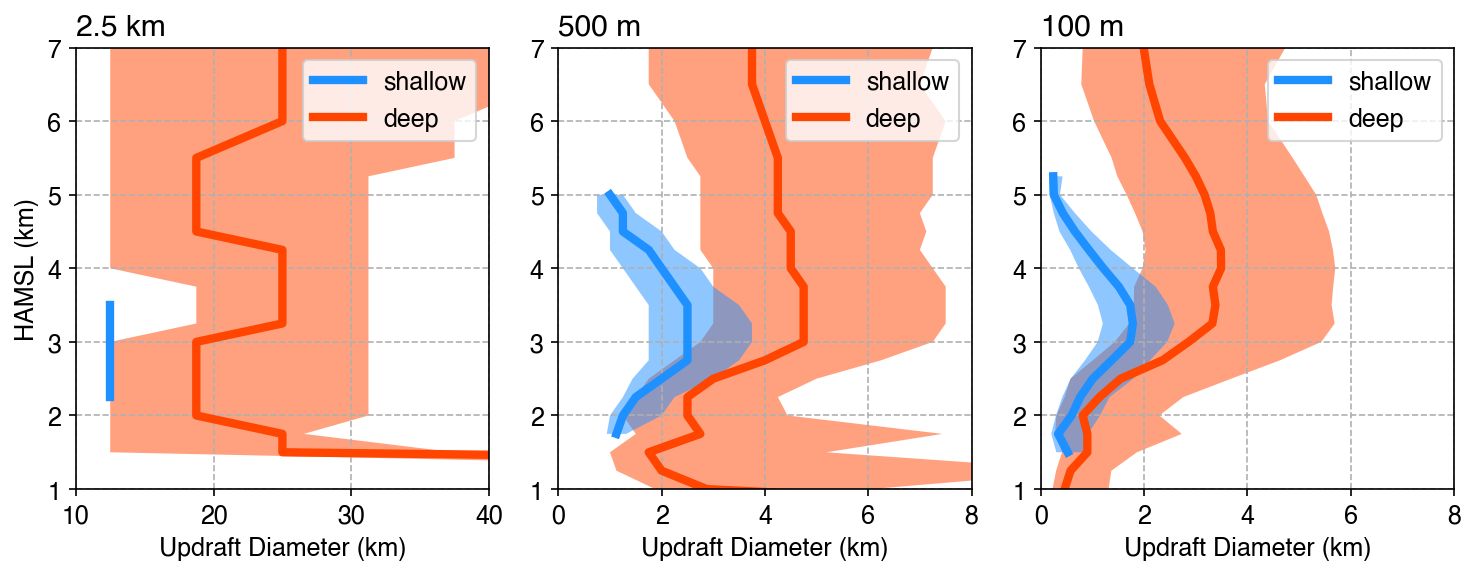

In [141]:
min_ns_shallow = 10
min_ns_deep = 10

dict_s = [
    {
        'line':trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= min_ns_shallow),
        'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_shallow_d2 >= min_ns_shallow),
                trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_shallow_d2 >= min_ns_shallow),],
    },
    {
        'line':trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= min_ns_shallow),
        'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_shallow_d3 >= min_ns_shallow),
                trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_shallow_d3 >= min_ns_shallow),],
    },
    {
        'line':trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= min_ns_shallow),
        'fill':[trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_shallow_d4 >= min_ns_shallow),
                trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_shallow_d4 >= min_ns_shallow),],
    },
]
dict_d = [
    {
        'line':trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_deep_d2 >= min_ns_deep),
        'fill':[trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_deep_d2 >= min_ns_deep),
               trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_deep_d2 >= min_ns_deep),],
    },
    {
        'line':trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_deep_d3 >= min_ns_deep),
        'fill':[trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_deep_d3 >= min_ns_deep),
               trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_deep_d3 >= min_ns_deep),],
    },
    {
        'line':trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_deep_d4 >= min_ns_deep),
        'fill':[trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_deep_d4 >= min_ns_deep),
               trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_deep_d4 >= min_ns_deep),],
    }, 
]

titles = ['2.5 km', '500 m', '100 m']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Diameter (km)']*3
xlims = [(10,40),(0,8),(0,8)]
ylims = [(1,7)]*3
figsize = (10,4)
fontsize = 12
figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'

fig = plot_profiles(1, 3, height, dict_s, dict_d,
                    titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

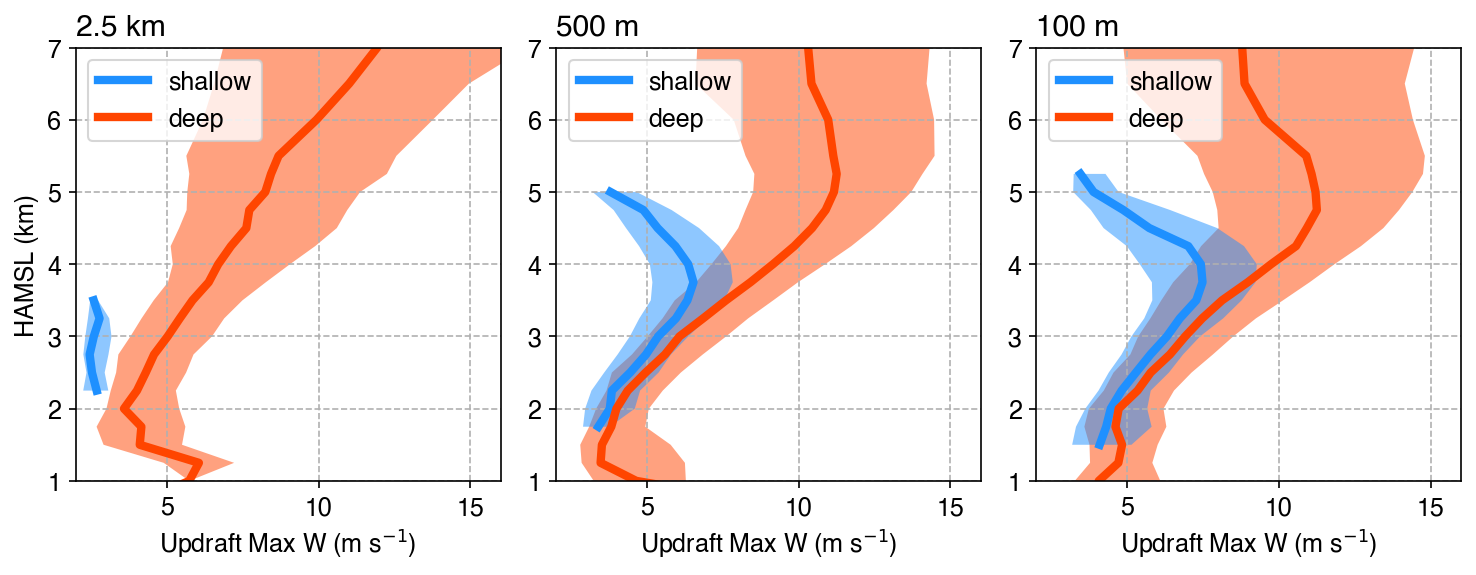

In [119]:
min_ns_shallow = 10
min_ns_deep = 10

dict_s = [
    {
        'line':trackmax_CoreMaxWUp_shallow_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= min_ns_shallow),
        'fill':[trackmax_CoreMaxWUp_shallow_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_shallow_d2 >= min_ns_shallow),
                trackmax_CoreMaxWUp_shallow_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_shallow_d2 >= min_ns_shallow),],
    },
    {
        'line':trackmax_CoreMaxWUp_shallow_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= min_ns_shallow),
        'fill':[trackmax_CoreMaxWUp_shallow_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_shallow_d3 >= min_ns_shallow),
                trackmax_CoreMaxWUp_shallow_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_shallow_d3 >= min_ns_shallow),],
    },
    {
        'line':trackmax_CoreMaxWUp_shallow_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= min_ns_shallow),
        'fill':[trackmax_CoreMaxWUp_shallow_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_shallow_d4 >= min_ns_shallow),
                trackmax_CoreMaxWUp_shallow_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_shallow_d4 >= min_ns_shallow),],
    },
]
dict_d = [
    {
        'line':trackmax_CoreMaxWUp_deep_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_deep_d2 >= min_ns_deep),
        'fill':[trackmax_CoreMaxWUp_deep_prof_pts_d2sub.sel(quantile=0.25).where(track_ns_init_deep_d2 >= min_ns_deep),
               trackmax_CoreMaxWUp_deep_prof_pts_d2sub.sel(quantile=0.75).where(track_ns_init_deep_d2 >= min_ns_deep),],
    },
    {
        'line':trackmax_CoreMaxWUp_deep_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_deep_d3 >= min_ns_deep),
        'fill':[trackmax_CoreMaxWUp_deep_prof_pts_d3sub.sel(quantile=0.25).where(track_ns_init_deep_d3 >= min_ns_deep),
               trackmax_CoreMaxWUp_deep_prof_pts_d3sub.sel(quantile=0.75).where(track_ns_init_deep_d3 >= min_ns_deep),],
    },
    {
        'line':trackmax_CoreMaxWUp_deep_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_deep_d4 >= min_ns_deep),
        'fill':[trackmax_CoreMaxWUp_deep_prof_pts_d4sub.sel(quantile=0.25).where(track_ns_init_deep_d4 >= min_ns_deep),
               trackmax_CoreMaxWUp_deep_prof_pts_d4sub.sel(quantile=0.75).where(track_ns_init_deep_d4 >= min_ns_deep),],
    }, 
]

titles = ['2.5 km', '500 m', '100 m']
ylabels = ['HAMSL (km)', '', '']
xlabels = ['Updraft Max W (m s$^{-1}$)']*3
xlims = [(2,16),(2,16),(2,16)]
# xlims = None
ylims = [(1,7)]*3
figsize = (10,4)
fontsize = 12
figname = f'{figdir}Updraft_CoreMaxW_profiles_shallow_deep_d2_d3_d4.png'

# ylims
fig = plot_profiles(1, 3, height, dict_s, dict_d,
                    titles=titles, xlables=xlabels, ylabels=ylabels, xlims=xlims, ylims=ylims, fontsize=fontsize, figsize=figsize, figname=figname)

In [121]:
# fig, axes = plt.subplots(1, 3, figsize=(10,4), dpi=150)

# lw = 4
# colors = {'s': 'dodgerblue', 'd': 'orangered'}

# ax = axes[0]
# med_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5)
# med_deep = trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10)
# ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
# ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
# x1_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.25)
# x2_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d2sub.sel(quantile=0.75)
# x1_deep = trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.25)
# x2_deep = trackmax_CoreAreaUp_deep_prof_pts_d2sub.sel(quantile=0.75)
# ax.fill_betweenx(height, x1_deep, x2_deep, facecolor=colors['d'], alpha=0.5)
# ax.fill_betweenx(height, x1_shallow, x2_shallow, facecolor=colors['s'], alpha=0.5)
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(10,40)

# ax = axes[1]
# med_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5)
# med_deep = trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10)
# ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
# ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
# x1_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.25)
# x2_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d3sub.sel(quantile=0.75)
# x1_deep = trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.25)
# x2_deep = trackmax_CoreAreaUp_deep_prof_pts_d3sub.sel(quantile=0.75)
# ax.fill_betweenx(height, x1_deep, x2_deep, facecolor=colors['d'], alpha=0.5)
# ax.fill_betweenx(height, x1_shallow, x2_shallow, facecolor=colors['s'], alpha=0.5)
# ax.legend()
# # ax.set_ylim(1,7)
# # ax.set_xlim(0,5)

# ax = axes[2]
# med_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5)
# med_deep = trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10)
# ax.plot(med_shallow, height, color=colors['s'], lw=lw, label='shallow')
# ax.plot(med_deep, height, color=colors['d'], lw=lw, label='deep')
# x1_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.25)
# x2_shallow = trackmax_CoreAreaUp_shallow_prof_pts_d4sub.sel(quantile=0.75)
# x1_deep = trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.25)
# x2_deep = trackmax_CoreAreaUp_deep_prof_pts_d4sub.sel(quantile=0.75)
# ax.fill_betweenx(height, x1_deep, x2_deep, facecolor=colors['d'], alpha=0.5)
# ax.fill_betweenx(height, x1_shallow, x2_shallow, facecolor=colors['s'], alpha=0.5)
# ax.legend()
# # ax.set_ylim(1,7)
# # ax.set_xlim(0,5)

# titles = ['2.5 km', '500 m', '100 m']
# ylabels = ['HAMSL (km)', '', '']
# xlabels = ['Updraft Width (km)']*3

# for pp in range(1,3):
#     axes[pp].set_ylim(1,7)
#     axes[pp].set_xlim(0,8)
# for pp in range(3):
#     axes[pp].grid(ls='--')
#     axes[pp].set_title(titles[pp], loc='left')
#     axes[pp].set_xlabel(xlabels[pp])
#     axes[pp].set_ylabel(ylabels[pp])

# fig.tight_layout()
# figname = f'{figdir}Updraft_CoreDiameter_profiles_shallow_deep_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

In [122]:
# prof_quantiles = [0.25, 0.5, 0.75]
# trackmax_CoreAreaUp_shallow_d2 = CoreArea_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d2 = trackmax_CoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d2 = CoreMaxW_up_shallow_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d2 = trackmax_CoreMaxWUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d2 = CoreArea_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d2 = trackmax_CoreAreaUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d2 = CoreMaxW_up_deep_d2.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d2 = trackmax_CoreMaxWUp_deep_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [123]:
# trackmax_CoreAreaUp_shallow_d3 = CoreArea_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d3 = trackmax_CoreAreaUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d3 = CoreMaxW_up_shallow_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d3 = trackmax_CoreMaxWUp_shallow_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d3 = CoreArea_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d3 = trackmax_CoreAreaUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d3 = CoreMaxW_up_deep_d3.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d3 = trackmax_CoreMaxWUp_deep_d3.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [124]:
# trackmax_CoreAreaUp_shallow_d4 = CoreArea_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_shallow_prof_pts_d4 = trackmax_CoreAreaUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_shallow_d4 = CoreMaxW_up_shallow_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_shallow_prof_pts_d4 = trackmax_CoreMaxWUp_shallow_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

# trackmax_CoreAreaUp_deep_d4 = CoreArea_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreAreaUp_deep_prof_pts_d4 = trackmax_CoreAreaUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# trackmax_CoreMaxWUp_deep_d4 = CoreMaxW_up_deep_d4.sel(times=slice(0,2)).max(dim='times')
# trackmax_CoreMaxWUp_deep_prof_pts_d4 = trackmax_CoreMaxWUp_deep_d4.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [125]:
# # Calculate total number of samples during initial times
# track_ns_init_shallow_d2 = nsample_CoreArea_up_shallow_d2.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d2 = nsample_CoreArea_up_deep_d2.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d3 = nsample_CoreArea_up_shallow_d3.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d3 = nsample_CoreArea_up_deep_d3.sel(times=slice(0,2)).sum(dim='times')

# track_ns_init_shallow_d4 = nsample_CoreArea_up_shallow_d4.sel(times=slice(0,2)).sum(dim='times')
# track_ns_init_deep_d4 = nsample_CoreArea_up_deep_d4.sel(times=slice(0,2)).sum(dim='times')

In [126]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150, sharey=True)
# axes = axes.ravel()

# ax = axes[0]
# ax.plot(track_ns_init_shallow_d2, height, color='b', label='D2 shallow')
# ax.plot(track_ns_init_deep_d2, height, color='r', label='D2 deep')
# ax.legend()

# ax = axes[1]
# ax.plot(track_ns_init_shallow_d3, height, color='b', label='D3 shallow')
# ax.plot(track_ns_init_deep_d3, height, color='r', label='D3 deep')
# ax.legend()

# ax = axes[2]
# ax.plot(track_ns_init_shallow_d4, height, color='b', label='D4 shallow')
# ax.plot(track_ns_init_deep_d4, height, color='r', label='D4 deep')
# ax.legend()

# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)

In [127]:
# track_ns_init_deep_d2

In [128]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(10,20)

# ax = axes[1]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

# ax = axes[2]
# ax.plot(trackmax_CoreAreaUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreAreaUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(0,5)

In [129]:
# fig, axes = plt.subplots(1, 3, figsize=(10,3), dpi=150)

# ax = axes[0]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_shallow_d2 >= 5), height, color='b', label='D2 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d2.sel(quantile=0.5).where(track_ns_init_deep_d2 >= 10), height, color='r', label='D2 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[1]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_shallow_d3 >= 5), height, color='b', label='D3 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d3.sel(quantile=0.5).where(track_ns_init_deep_d3 >= 10), height, color='r', label='D3 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

# ax = axes[2]
# ax.plot(trackmax_CoreMaxWUp_shallow_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_shallow_d4 >= 5), height, color='b', label='D4 shallow')
# ax.plot(trackmax_CoreMaxWUp_deep_prof_pts_d4.sel(quantile=0.5).where(track_ns_init_deep_d4 >= 10), height, color='r', label='D4 deep')
# ax.legend()
# ax.set_ylim(1,7)
# ax.set_xlim(2,10)

In [130]:
# prof_quantiles = [0.25, 0.5, 0.75]
# maxCoreAreaUp_shallow_d2 = dss_d2.CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# # maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)
# maxCoreAreaUp_shallow_prof_pts_d2 = maxCoreAreaUp_shallow_d2.where(maxCoreAreaUp_shallow_d2.z <= max10dbz_pts_d2[0]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [132]:
# maxCoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1)).max(dim='times')
# maxCoreAreaUp_deep_prof_pts_d2 = maxCoreAreaUp_deep_d2.where(maxCoreAreaUp_deep_d2.z <= max10dbz_pts_d2[2]*1000).quantile(prof_quantiles, dim='tracks', keep_attrs=True, skipna=True)

In [133]:
# ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0])

In [134]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.5).plot()
# maxCoreAreaUp_deep_prof_pts_d2.sel(quantile=0.5).plot()

In [135]:
# maxCoreAreaUp_shallow_prof_pts_d2.sel(quantile=0.75).plot()

In [136]:
# max10dbz_d2

In [137]:
# CoreAreaUp_shallow_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 <= max10dbz_pts_d2[0], drop=True).isel(core=0).chunk(dict(tracks=-1))
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).chunk(dict(tracks=-1))

In [138]:
# CoreAreaUp_deep_d2 = ds_d2.isel(tracks=tid_d2['nms']).CoreArea_up.where(max10dbz_d2 >= max10dbz_pts_d2[2], drop=True).isel(core=0).load()

In [139]:
# # ds_d2.times
# time_res = 5.0  # [min]
# xtime = ds_d2.times * time_res
# height = ds_d2.z / 1000.